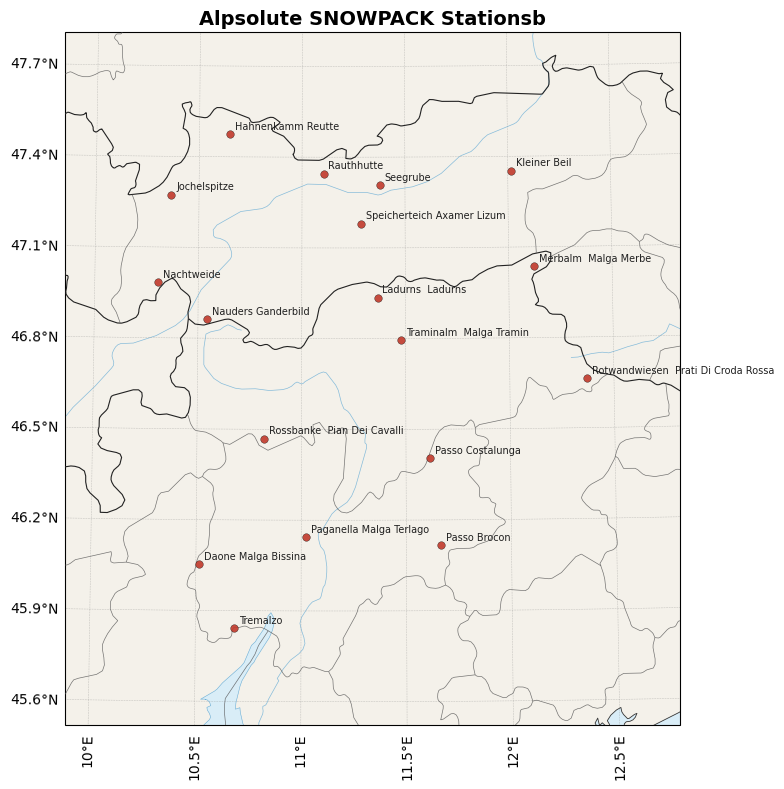

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load dataset (works from repo root or this notebook folder)
csv_candidates = [
    Path("par_sens/SNOWPACK_data/data<2000m/processed/AAA_station_meate.csv"),
    Path("../../par_sens/SNOWPACK_data/data<2000m/processed/AAA_station_meta.csv"),
]
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find AAA_station_meate.csv from current directory.")
df = pd.read_csv(csv_path)

# Try to find latitude/longitude columns automatically
lat_candidates = ["lat", "latitude", "y", "y_coord", "northing"]
lon_candidates = ["lon", "long", "longitude", "x", "x_coord", "easting"]
name_candidates = ["station_name", "name", "station", "station_id", "id"]

cols_lower = {c.lower(): c for c in df.columns}
lat_col = next((cols_lower[c] for c in lat_candidates if c in cols_lower), None)
lon_col = next((cols_lower[c] for c in lon_candidates if c in cols_lower), None)
name_col = next((cols_lower[c] for c in name_candidates if c in cols_lower), None)

if lat_col is None or lon_col is None:
    raise ValueError(
        f"Could not find latitude/longitude columns. Available columns: {list(df.columns)}"
    )

# Drop rows with missing coordinates and keep station labels
plot_cols = [lon_col, lat_col] + ([name_col] if name_col is not None else [])
plot_df = df[plot_cols].dropna(subset=[lon_col, lat_col]).copy()
plot_df["label"] = plot_df[name_col].astype(str) if name_col is not None else plot_df.index.astype(str)

if plot_df.empty:
    raise ValueError("No valid station coordinates found after dropping missing values.")

# Build map extent with small padding
lon_min, lon_max = plot_df[lon_col].min(), plot_df[lon_col].max()
lat_min, lat_max = plot_df[lat_col].min(), plot_df[lat_col].max()
lon_pad = max(0.35, (lon_max - lon_min) * 0.2)
lat_pad = max(0.25, (lat_max - lat_min) * 0.2)
extent = [lon_min - lon_pad, lon_max + lon_pad, lat_min - lat_pad, lat_max + lat_pad]

PC = ccrs.PlateCarree()

# Use a conformal regional projection to reduce distortion over the Alps.
center_lon = float(plot_df[lon_col].mean())
center_lat = float(plot_df[lat_col].mean())
PROJ = ccrs.LambertConformal(
    central_longitude=center_lon,
    central_latitude=center_lat,
    standard_parallels=(44.0, 49.0),
)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": PROJ})
ax.set_extent(extent, crs=PC)

# Background map layers
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#d9edf7", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#f4f1ea", zorder=0)
ax.add_feature(cfeature.LAKES.with_scale("10m"), facecolor="#d9edf7", edgecolor="#6aaed6", linewidth=0.4, zorder=1)
ax.add_feature(cfeature.RIVERS.with_scale("10m"), edgecolor="#6aaed6", linewidth=0.5, alpha=0.8, zorder=2)
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.6, edgecolor="#333333", zorder=3)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.8, edgecolor="#222222", zorder=4)

# Province/state borders (Natural Earth admin-1 boundaries)
admin1 = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none",
)
ax.add_feature(admin1, edgecolor="#555555", linewidth=0.5, alpha=0.8, zorder=4)

# Station points
ax.scatter(
    plot_df[lon_col],
    plot_df[lat_col],
    s=30,
    alpha=0.9,
    edgecolor="k",
    linewidth=0.25,
    color="#c0392b",
    transform=PC,
    zorder=6,
)

# Plot station names next to points
dx = (extent[1] - extent[0]) * 0.008
dy = (extent[3] - extent[2]) * 0.008
for _, row in plot_df.iterrows():
    ax.text(
        row[lon_col] + dx,
        row[lat_col] + dy,
        row["label"],
        transform=PC,
        fontsize=7,
        color="#1f1f1f",
        zorder=7,
    )

gl = ax.gridlines(draw_labels=True, linewidth=0.35, color="gray", alpha=0.45, linestyle="--")
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.x_inline = False
gl.y_inline = False

ax.set_title("Alpsolute SNOWPACK Stationsb", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Loaded 36 files, 6,473 total rows.
After filter (HS > 10 cm, SWE > 0): 5,601 rows.


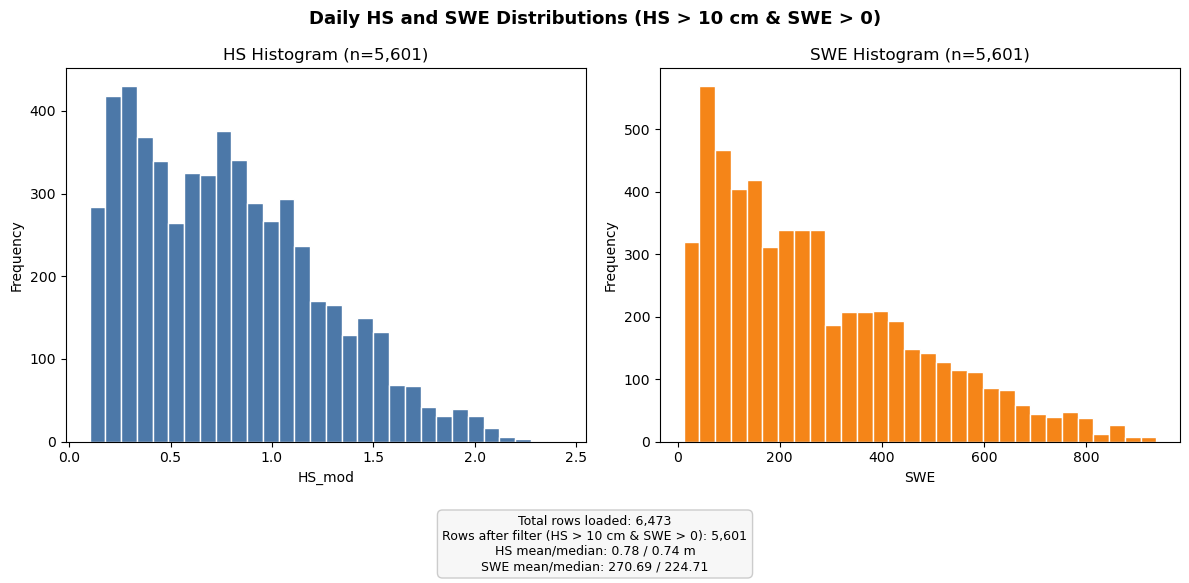

In [20]:
# Load and concatenate all daily HS/SWE CSV files (skip the station metadata file)
processed_dir_candidates = [
    Path("par_sens/SNOWPACK_data/data<2000m/processed"),
    Path("../../par_sens/SNOWPACK_data/data<2000m/processed"),
]
processed_dir = next((p for p in processed_dir_candidates if p.is_dir()), None)
if processed_dir is None:
    raise FileNotFoundError("Could not find processed data directory.")

daily_files = [
    p for p in sorted(processed_dir.glob("*.csv"))
    if not p.name.startswith("AAA_")
]
if not daily_files:
    raise FileNotFoundError("No daily CSV files found in the processed directory.")

daily_df = pd.concat([pd.read_csv(f) for f in daily_files], ignore_index=True)
print(f"Loaded {len(daily_files)} files, {len(daily_df):,} total rows.")

# Auto-detect HS/SWE columns
daily_cols_lower = {c.lower().strip(): c for c in daily_df.columns}
hs_candidates = ["hs_mod", "hs_meas", "hs", "snow_height", "snowdepth", "snow_depth"]
swe_candidates = ["swe", "snow_water_equivalent"]

hs_col = next((daily_cols_lower[c] for c in hs_candidates if c in daily_cols_lower), None)
swe_col = next((daily_cols_lower[c] for c in swe_candidates if c in daily_cols_lower), None)

if hs_col is None or swe_col is None:
    raise ValueError(
        f"Could not detect HS/SWE columns. Available columns: {list(daily_df.columns)}"
    )

# Clean numeric values
daily_df[hs_col] = pd.to_numeric(daily_df[hs_col], errors="coerce")
daily_df[swe_col] = pd.to_numeric(daily_df[swe_col], errors="coerce")

# Filter: HS > 0.10 m and SWE > 0
filtered_df = daily_df[
    (daily_df[hs_col] > 0.10) &
    (daily_df[swe_col] > 0)
].copy()
print(f"After filter (HS > 10 cm, SWE > 0): {len(filtered_df):,} rows.")

hs_data = filtered_df[hs_col].dropna()
swe_data = filtered_df[swe_col].dropna()

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(hs_data, bins=30, color="#4C78A8", edgecolor="white")
axes[0].set_title(f"HS Histogram (n={len(hs_data):,})")
axes[0].set_xlabel(hs_col)
axes[0].set_ylabel("Frequency")

axes[1].hist(swe_data, bins=30, color="#F58518", edgecolor="white")
axes[1].set_title(f"SWE Histogram (n={len(swe_data):,})")
axes[1].set_xlabel(swe_col)
axes[1].set_ylabel("Frequency")

summary_text = (
    f"Total rows loaded: {len(daily_df):,}\n"
    f"Rows after filter (HS > 10 cm & SWE > 0): {len(filtered_df):,}\n"
    f"HS mean/median: {hs_data.mean():.2f} / {hs_data.median():.2f} m\n"
    f"SWE mean/median: {swe_data.mean():.2f} / {swe_data.median():.2f}"
)
fig.text(
    0.5, -0.03, summary_text, ha="center", va="top",
    fontsize=9, bbox=dict(boxstyle="round,pad=0.4", facecolor="#f7f7f7", edgecolor="#cccccc")
)

fig.suptitle("Daily HS and SWE Distributions (HS > 10 cm & SWE > 0)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

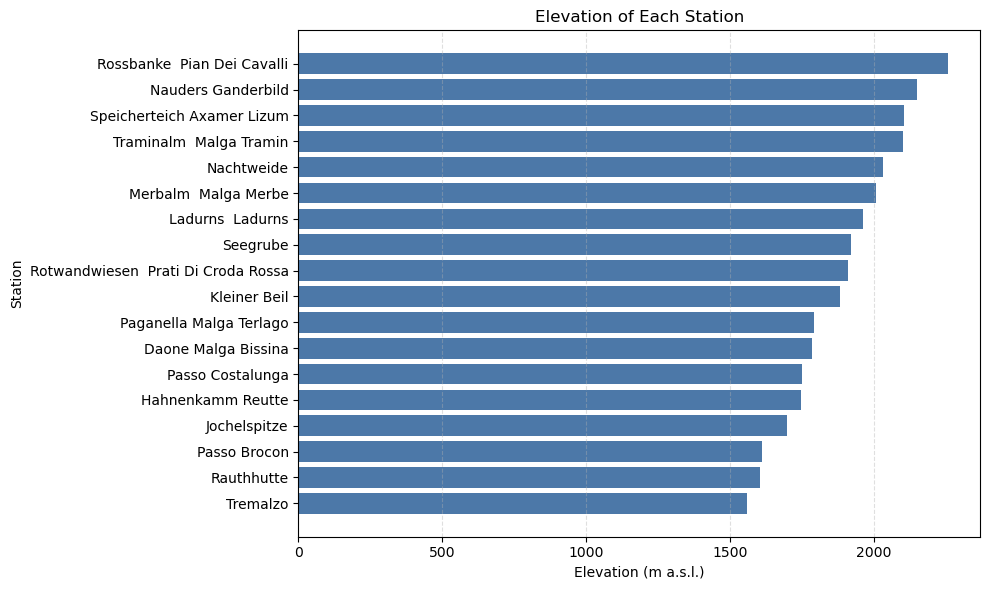

In [21]:
# Plot station elevation (altitude) for each station
elev_df = df[["station_name", "altitude"]].dropna().sort_values("altitude")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(elev_df["station_name"], elev_df["altitude"], color="#4C78A8")

ax.set_xlabel("Elevation (m a.s.l.)")
ax.set_ylabel("Station")
ax.set_title("Elevation of Each Station")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()